In [2]:
# -*- coding: utf-8 -*-
"""XU_LY_DONATEACRY_HOAN_CHINH_RMS_NORM_WITH_CLASS_FOLDERS.ipynb
XỬ LÝ DONATE-A-CRY - DÙNG RMS NORMALIZATION - CHIA THƯ MỤC THEO LỚP
(CÓ XUẤT METADATA UUID)
"""

import os
import subprocess
import librosa
import soundfile as sf
import numpy as np
from tqdm import tqdm
from collections import Counter
import shutil
import pandas as pd

# ============================================
# KHAI BÁO ĐƯỜNG DẪN - ĐÃ SỬA
# ============================================
DONATEACRY_PATH = r'C:\mangcambien\donateacry-corpus-master'
OUTPUT_BASE_PATH = r'C:\mangcambien\data_da_xu_ly\baby_cry_by_reason'  # Thư mục gốc chứa các lớp
FFMPEG_PATH = r'C:\ffmpeg\ffmpeg-8.0.1-full_build\bin\ffmpeg.exe'

# Tham số chuẩn
TARGET_SR = 22050
TARGET_DURATION = 5
TARGET_RMS = 0.1  # RMS target cho normalization

# CHỈ GIỮ LẠI 5 LỚP MONG MUỐN
TARGET_CLASSES = ['hungry', 'tired', 'belly_pain', 'discomfort', 'burping']

# Mapping reason code -> tên lớp
REASON_MAPPING = {
    'hu': 'hungry',
    'bu': 'burping',
    'bp': 'belly_pain',
    'dc': 'discomfort',
    'ti': 'tired',
    'lo': 'lonely',      # Sẽ bỏ qua
    'ch': 'cold_hot',     # Sẽ bỏ qua
    'sc': 'scared',       # Sẽ bỏ qua
    'dk': 'unknown'       # Sẽ bỏ qua
}

print("="*80)
print("📊 TIỀN XỬ LÝ DONATE-A-CRY - RMS NORMALIZATION")
print("="*80)
print(f"🎯 CHỈ GIỮ LẠI 5 LỚP: {TARGET_CLASSES}")

# ============================================
# KIỂM TRA FFMPEG
# ============================================
def check_ffmpeg():
    if not os.path.exists(FFMPEG_PATH):
        print(f"❌ Không tìm thấy FFmpeg tại: {FFMPEG_PATH}")
        return False
    try:
        result = subprocess.run([FFMPEG_PATH, '-version'], capture_output=True, text=True)
        if result.returncode == 0:
            print(f"✅ FFmpeg OK")
            return True
    except:
        return False

if not check_ffmpeg():
    print("❌ FFmpeg không hoạt động. Thoát!")
    exit()

# ============================================
# TÌM TẤT CẢ FILE GỐC
# ============================================
print("\n🔍 ĐANG TÌM FILE GỐC...")

file_details = []
for root, dirs, files in os.walk(DONATEACRY_PATH):
    for file in files:
        ext = os.path.splitext(file)[1].lower()
        if ext in ['.wav', '.caf', '.mp3', '.ogg', '.m4a', '.3gp']:
            full_path = os.path.join(root, file)
            basename = os.path.basename(file)
            name = os.path.splitext(basename)[0]
            parts = name.split('-')
            
            # Xác định ID (UUID) và reason code
            if len(parts) >= 2:
                file_id = '-'.join(parts[:-1])
                reason_code = parts[-1].lower()[:2]
            else:
                file_id = name
                reason_code = 'unknown'
            
            reason_name = REASON_MAPPING.get(reason_code, 'unknown')
            
            file_details.append({
                'path': full_path,
                'name': file,
                'ext': ext,
                'id': file_id,
                'reason_code': reason_code,
                'reason_name': reason_name,
                'is_target': reason_name in TARGET_CLASSES
            })

print(f"📁 Tổng số file tìm thấy: {len(file_details)}")

# ============================================
# THỐNG KÊ BAN ĐẦU
# ============================================
print("\n📊 THỐNG KÊ BAN ĐẦU:")

ext_stats = Counter(d['ext'] for d in file_details)
print("\n📁 Theo định dạng:")
for ext, count in ext_stats.most_common():
    print(f"   {ext:6}: {count:4d} file")

# Thống kê theo reason code
reason_stats = Counter(d['reason_name'] for d in file_details if d['reason_name'] != 'unknown')
print("\n🎯 Theo reason (tất cả):")
for reason, count in reason_stats.most_common():
    percent = count / len(file_details) * 100
    in_target = "✅" if reason in TARGET_CLASSES else "❌"
    print(f"   {reason:12}: {count:4d} file ({percent:5.2f}%) {in_target}")

# ============================================
# LỌC CHỈ GIỮ LẠI 5 LỚP MỤC TIÊU
# ============================================
print("\n🎯 LỌC CHỈ GIỮ LẠI 5 LỚP MỤC TIÊU:")
target_files = [d for d in file_details if d['is_target']]

target_stats = Counter(d['reason_name'] for d in target_files)
print("\n📊 Phân bố 5 lớp mục tiêu:")
for reason in TARGET_CLASSES:
    count = target_stats.get(reason, 0)
    print(f"   {reason:12}: {count:4d} file")

print(f"\n✅ Tổng số file giữ lại: {len(target_files)} file")

# ============================================
# HÀM RMS NORMALIZATION
# ============================================
def rms_normalize(y, target_rms=TARGET_RMS):
    rms = np.sqrt(np.mean(y**2))
    if rms > 0:
        y = y * (target_rms / rms)
    return y

# ============================================
# XỬ LÝ FILE - CHIA VÀO THƯ MỤC THEO LỚP
# ============================================
print("\n🔄 ĐANG XỬ LÝ FILE...")

# Xóa thư mục output cũ nếu có
if os.path.exists(OUTPUT_BASE_PATH):
    shutil.rmtree(OUTPUT_BASE_PATH)

# Tạo thư mục cho từng lớp
for class_name in TARGET_CLASSES:
    class_path = os.path.join(OUTPUT_BASE_PATH, class_name)
    os.makedirs(class_path, exist_ok=True)
    print(f"📁 Đã tạo thư mục: {class_path}")

temp_dir = os.path.join(OUTPUT_BASE_PATH, 'temp')
os.makedirs(temp_dir, exist_ok=True)

success = 0
failed = 0
error_files = []
rms_values = []  # Lưu RMS để kiểm tra
class_counts = {class_name: 0 for class_name in TARGET_CLASSES}

# Danh sách metadata để xuất
metadata_list = []

for i, file_info in enumerate(tqdm(target_files, desc="Xử lý")):
    file_path = file_info['path']
    ext = file_info['ext']
    reason_name = file_info['reason_name']
    uuid = file_info['id']   # UUID của em bé
    
    # Xác định thư mục output dựa trên lớp
    output_dir = os.path.join(OUTPUT_BASE_PATH, reason_name)
    os.makedirs(output_dir, exist_ok=True)
    
    # Đặt tên file với số thứ tự
    class_counts[reason_name] += 1
    file_index = class_counts[reason_name]
    output_filename = f"{reason_name}_{file_index:05d}.wav"
    output_file = os.path.join(output_dir, output_filename)
    
    try:
        if ext == '.wav':
            # Xử lý trực tiếp file WAV
            y, sr = librosa.load(file_path, sr=None, mono=True)
            
            # Resample nếu cần
            if sr != TARGET_SR:
                y = librosa.resample(y, orig_sr=sr, target_sr=TARGET_SR)
            
            # Cắt hoặc padding về 5 giây
            target_length = TARGET_DURATION * TARGET_SR
            if len(y) > target_length:
                start = (len(y) - target_length) // 2
                y = y[start:start + target_length]
            elif len(y) < target_length:
                y = np.pad(y, (0, target_length - len(y)), 'constant')
            
            # RMS Normalization
            y = rms_normalize(y)
            rms_after = np.sqrt(np.mean(y**2))
            rms_values.append(rms_after)
            
            # Lưu file
            sf.write(output_file, y, TARGET_SR, subtype='PCM_16')
            success += 1
        else:
            # File khác: dùng FFmpeg convert trước
            temp_file = os.path.join(temp_dir, f"temp_{i}.wav")
            
            cmd = [
                FFMPEG_PATH,
                '-i', file_path,
                '-ac', '1',
                '-ar', str(TARGET_SR),
                '-y',
                temp_file
            ]
            
            result = subprocess.run(cmd, capture_output=True, timeout=120)
            
            if result.returncode == 0 and os.path.exists(temp_file):
                y, sr = librosa.load(temp_file, sr=None, mono=True)
                
                target_length = TARGET_DURATION * TARGET_SR
                if len(y) > target_length:
                    start = (len(y) - target_length) // 2
                    y = y[start:start + target_length]
                elif len(y) < target_length:
                    y = np.pad(y, (0, target_length - len(y)), 'constant')
                
                # RMS Normalization
                y = rms_normalize(y)
                rms_after = np.sqrt(np.mean(y**2))
                rms_values.append(rms_after)
                
                sf.write(output_file, y, TARGET_SR, subtype='PCM_16')
                success += 1
                
                if os.path.exists(temp_file):
                    os.remove(temp_file)
            else:
                failed += 1
                error_files.append(file_info['name'])
                continue
                
    except Exception as e:
        print(f"\n❌ Lỗi {file_info['name']}: {e}")
        failed += 1
        error_files.append(file_info['name'])
        continue
    
    # Lưu metadata (ánh xạ giữa file đầu ra và uuid)
    metadata_list.append({
        'filename': output_filename,
        'class': reason_name,
        'uuid': uuid,
        'original_file': file_info['name']
    })

# Dọn dẹp thư mục tạm
try:
    shutil.rmtree(temp_dir)
except:
    pass

# ============================================
# XUẤT METADATA
# ============================================
metadata_df = pd.DataFrame(metadata_list)
metadata_path = os.path.join(OUTPUT_BASE_PATH, 'metadata_uuid.csv')
metadata_df.to_csv(metadata_path, index=False)
print(f"\n💾 Đã lưu metadata kèm UUID tại: {metadata_path}")

# ============================================
# KẾT QUẢ CUỐI CÙNG
# ============================================
print("\n" + "="*80)
print("📊 KẾT QUẢ XỬ LÝ DONATE-A-CRY")
print("="*80)
print(f"""
✅ THÀNH CÔNG: {success} file
❌ THẤT BẠI: {failed} file
📁 OUTPUT: {OUTPUT_BASE_PATH}
""")

print("\n📊 PHÂN BỐ FILE THEO LỚP:")
for class_name in TARGET_CLASSES:
    class_path = os.path.join(OUTPUT_BASE_PATH, class_name)
    if os.path.exists(class_path):
        file_count = len([f for f in os.listdir(class_path) if f.endswith('.wav')])
        print(f"   {class_name:12}: {file_count:4d} file")
    else:
        print(f"   {class_name:12}: {0:4d} file (❌ không tồn tại)")

if error_files:
    print("\n📋 DANH SÁCH FILE LỖI (10 file đầu):")
    for f in error_files[:10]:
        print(f"   - {f}")

# ============================================
# KIỂM TRA RMS
# ============================================
print("\n📊 THỐNG KÊ RMS SAU NORMALIZATION:")
if rms_values:
    rms_array = np.array(rms_values)
    print(f"   - Mean RMS: {rms_array.mean():.4f} (target: {TARGET_RMS})")
    print(f"   - Std RMS: {rms_array.std():.4f}")
    print(f"   - Min RMS: {rms_array.min():.4f}")
    print(f"   - Max RMS: {rms_array.max():.4f}")
    print(f"   - % files trong khoảng [{TARGET_RMS*0.9:.4f}, {TARGET_RMS*1.1:.4f}]: "
          f"{np.sum((rms_array >= TARGET_RMS*0.9) & (rms_array <= TARGET_RMS*1.1)) / len(rms_array) * 100:.1f}%")

# ============================================
# KIỂM TRA CHẤT LƯỢNG 5 FILE ĐẦU (mỗi lớp 1 file)
# ============================================
print("\n🔍 KIỂM TRA CHẤT LƯỢNG MẪU ĐẠI DIỆN (1 FILE/LỚP):")
for class_name in TARGET_CLASSES:
    class_path = os.path.join(OUTPUT_BASE_PATH, class_name)
    if os.path.exists(class_path):
        files = [f for f in os.listdir(class_path) if f.endswith('.wav')]
        if files:
            sample_file = files[0]
            file_path = os.path.join(class_path, sample_file)
            y, sr = librosa.load(file_path, sr=None)
            duration = len(y) / sr
            rms = np.sqrt(np.mean(y**2))
            print(f"\n   📄 {class_name}: {sample_file}")
            print(f"      - Sample rate: {sr} Hz")
            print(f"      - Duration: {duration:.2f}s")
            print(f"      - Amplitude: [{y.min():.3f}, {y.max():.3f}]")
            print(f"      - RMS: {rms:.4f}")

# ============================================
# LƯU LOG (không bắt buộc)
# ============================================
log_data = []
for class_name in TARGET_CLASSES:
    class_path = os.path.join(OUTPUT_BASE_PATH, class_name)
    if os.path.exists(class_path):
        files = [f for f in os.listdir(class_path) if f.endswith('.wav')]
        for f in files:
            file_path = os.path.join(class_path, f)
            y, sr = librosa.load(file_path, sr=None)
            duration = len(y) / sr
            rms = np.sqrt(np.mean(y**2))
            
            log_data.append({
                'filename': f,
                'class': class_name,
                'sample_rate': sr,
                'duration': duration,
                'amplitude_min': y.min(),
                'amplitude_max': y.max(),
                'rms': rms,
                'status': 'OK'
            })

log_df = pd.DataFrame(log_data)
log_path = os.path.join(OUTPUT_BASE_PATH, '..', 'donateacry_processed_log_rms.csv')
log_df.to_csv(log_path, index=False)
print(f"\n💾 Đã lưu log tại: {log_path}")

print("\n" + "="*80)
print("✅ HOÀN TẤT XỬ LÝ DONATE-A-CRY VỚI RMS NORMALIZATION!")
print(f"📁 Dữ liệu đã được chia vào các thư mục: {OUTPUT_BASE_PATH}")
print(f"📄 Metadata UUID đã lưu tại: {metadata_path}")
print("="*80)

📊 TIỀN XỬ LÝ DONATE-A-CRY - RMS NORMALIZATION
🎯 CHỈ GIỮ LẠI 5 LỚP: ['hungry', 'tired', 'belly_pain', 'discomfort', 'burping']
✅ FFmpeg OK

🔍 ĐANG TÌM FILE GỐC...
📁 Tổng số file tìm thấy: 1585

📊 THỐNG KÊ BAN ĐẦU:

📁 Theo định dạng:
   .3gp  :  712 file
   .wav  :  457 file
   .caf  :  416 file

🎯 Theo reason (tất cả):
   hungry      : 1124 file (70.91%) ✅
   tired       :   84 file ( 5.30%) ✅
   discomfort  :   58 file ( 3.66%) ✅
   belly_pain  :   43 file ( 2.71%) ✅
   burping     :   25 file ( 1.58%) ✅
   lonely      :   23 file ( 1.45%) ❌
   cold_hot    :   19 file ( 1.20%) ❌
   scared      :   15 file ( 0.95%) ❌

🎯 LỌC CHỈ GIỮ LẠI 5 LỚP MỤC TIÊU:

📊 Phân bố 5 lớp mục tiêu:
   hungry      : 1124 file
   tired       :   84 file
   belly_pain  :   43 file
   discomfort  :   58 file
   burping     :   25 file

✅ Tổng số file giữ lại: 1334 file

🔄 ĐANG XỬ LÝ FILE...
📁 Đã tạo thư mục: C:\mangcambien\data_da_xu_ly\baby_cry_by_reason\hungry
📁 Đã tạo thư mục: C:\mangcambien\data_da_xu_ly\ba

Xử lý: 100%|███████████████████████████████████████████████████████████████████████| 1334/1334 [00:53<00:00, 24.92it/s]



💾 Đã lưu metadata kèm UUID tại: C:\mangcambien\data_da_xu_ly\baby_cry_by_reason\metadata_uuid.csv

📊 KẾT QUẢ XỬ LÝ DONATE-A-CRY

✅ THÀNH CÔNG: 1334 file
❌ THẤT BẠI: 0 file
📁 OUTPUT: C:\mangcambien\data_da_xu_ly\baby_cry_by_reason


📊 PHÂN BỐ FILE THEO LỚP:
   hungry      : 1124 file
   tired       :   84 file
   belly_pain  :   43 file
   discomfort  :   58 file
   burping     :   25 file

📊 THỐNG KÊ RMS SAU NORMALIZATION:
   - Mean RMS: 0.0999 (target: 0.1)
   - Std RMS: 0.0039
   - Min RMS: 0.0000
   - Max RMS: 0.1000
   - % files trong khoảng [0.0900, 0.1100]: 99.9%

🔍 KIỂM TRA CHẤT LƯỢNG MẪU ĐẠI DIỆN (1 FILE/LỚP):

   📄 hungry: hungry_00001.wav
      - Sample rate: 22050 Hz
      - Duration: 5.00s
      - Amplitude: [-0.751, 0.695]
      - RMS: 0.1000

   📄 tired: tired_00001.wav
      - Sample rate: 22050 Hz
      - Duration: 5.00s
      - Amplitude: [-1.000, 1.000]
      - RMS: 0.0889

   📄 belly_pain: belly_pain_00001.wav
      - Sample rate: 22050 Hz
      - Duration: 5.00s
  

🎯 PHÂN LOẠI 5 NGUYÊN NHÂN KHÓC - DONATE-A-CRY (GroupKFold theo UUID)
📁 Data path: C:\mangcambien\data_da_xu_ly\baby_cry_by_reason
🎯 Các lớp: ['hungry', 'tired', 'belly_pain', 'discomfort', 'burping']

📊 ĐỌC METADATA VÀ TẠO DATASET...
📄 Đã đọc metadata: 1334 file
📁 hungry: 1124 files gốc


Xử lý hungry: 100%|████████████████████████████████████████████████████████████████| 1124/1124 [00:13<00:00, 80.72it/s]


📁 tired: 84 files gốc


Xử lý tired: 100%|█████████████████████████████████████████████████████████████████████| 84/84 [00:20<00:00,  4.05it/s]


📁 belly_pain: 43 files gốc


...

📁 discomfort: 58 files gốc


Xử lý discomfort: 100%|████████████████████████████████████████████████████████████████| 58/58 [00:14<00:00,  4.02it/s]


📁 burping: 25 files gốc


Xử lý burping: 100%|███████████████████████████████████████████████████████████████████| 25/25 [00:06<00:00,  4.04it/s]



📊 THỐNG KÊ SAU KHI TẠO DATASET:
   hungry      : 1124 mẫu (47.15%)
   tired       :  504 mẫu (21.14%)
   belly_pain  :  258 mẫu (10.82%)
   discomfort  :  348 mẫu (14.60%)
   burping     :  150 mẫu ( 6.29%)

✅ Tổng số mẫu: 2384
✅ Số UUID duy nhất: 884

📋 Thứ tự lớp trong label_encoder:
   0: belly_pain
   1: burping
   2: discomfort
   3: hungry
   4: tired

🤖 ĐỊNH NGHĨA CÁC MODELS...

🔍 SỬ DỤNG GroupKFold (n_splits=5) DỰA TRÊN UUID...

📌 FOLD 1/5
   Train samples: 1907, Test samples: 477

📌 FOLD 2/5
   Train samples: 1907, Test samples: 477

📌 FOLD 3/5
   Train samples: 1907, Test samples: 477

📌 FOLD 4/5
   Train samples: 1907, Test samples: 477

📌 FOLD 5/5
   Train samples: 1908, Test samples: 476

📊 KẾT QUẢ TRUNG BÌNH 5-FOLD (GROUPKFOLD)

Random Forest:
   Accuracy: 0.5264 ± 0.0264
   F1 Macro: 0.3205 ± 0.0435
   F1 Weighted: 0.4785 ± 0.0302

SVM (RBF):
   Accuracy: 0.5273 ± 0.0276
   F1 Macro: 0.3208 ± 0.0346
   F1 Weighted: 0.4822 ± 0.0275

XGBoost:
   Accuracy: 0.5398 ± 0.0264


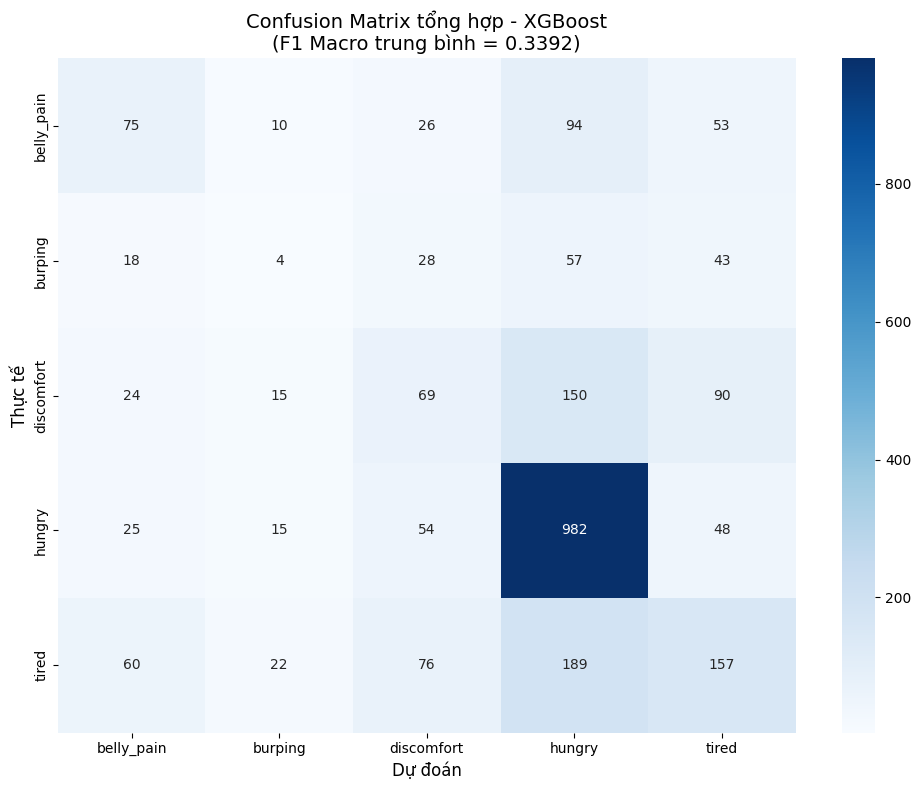


📊 Chi tiết từng lớp:

belly_pain:
   → belly_pain: 75 mẫu
   → burping: 10 mẫu
   → discomfort: 26 mẫu
   → hungry: 94 mẫu
   → tired: 53 mẫu
   ✅ Đúng: 75/258 (29.1%)

burping:
   → belly_pain: 18 mẫu
   → burping: 4 mẫu
   → discomfort: 28 mẫu
   → hungry: 57 mẫu
   → tired: 43 mẫu
   ✅ Đúng: 4/150 (2.7%)

discomfort:
   → belly_pain: 24 mẫu
   → burping: 15 mẫu
   → discomfort: 69 mẫu
   → hungry: 150 mẫu
   → tired: 90 mẫu
   ✅ Đúng: 69/348 (19.8%)

hungry:
   → belly_pain: 25 mẫu
   → burping: 15 mẫu
   → discomfort: 54 mẫu
   → hungry: 982 mẫu
   → tired: 48 mẫu
   ✅ Đúng: 982/1124 (87.4%)

tired:
   → belly_pain: 60 mẫu
   → burping: 22 mẫu
   → discomfort: 76 mẫu
   → hungry: 189 mẫu
   → tired: 157 mẫu
   ✅ Đúng: 157/504 (31.2%)

💾 LƯU KẾT QUẢ...
✅ Đã lưu model_comparison_5classes_groupkfold.csv

✅ HOÀN TẤT! Kết quả đã được lưu.


In [8]:
# -*- coding: utf-8 -*-
"""PHAN_LOAI_5_LOP_NGUYEN_NHAN_KHOC_WITH_GROUPKFOLD.ipynb
Phân loại 5 nguyên nhân khóc từ Donate-A-Cry: hungry, tired, belly_pain, discomfort, burping
Sử dụng GroupKFold dựa trên UUID để tránh data leakage
"""

import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 1. IMPORT CÁC THƯ VIỆN CẦN THIẾT
# ============================================
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, 
                             f1_score, accuracy_score, precision_score, recall_score)
from sklearn.utils.class_weight import compute_class_weight

# Các model
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Xử lý mất cân bằng lớp
from imblearn.over_sampling import SMOTE

# ============================================
# 2. KHAI BÁO ĐƯỜNG DẪN
# ============================================
DATA_PATH = r'C:\mangcambien\data_da_xu_ly\baby_cry_by_reason'
METADATA_PATH = os.path.join(DATA_PATH, 'metadata_uuid.csv')
CLASSES = ['hungry', 'tired', 'belly_pain', 'discomfort', 'burping']

print("="*80)
print("🎯 PHÂN LOẠI 5 NGUYÊN NHÂN KHÓC - DONATE-A-CRY (GroupKFold theo UUID)")
print("="*80)
print(f"📁 Data path: {DATA_PATH}")
print(f"🎯 Các lớp: {CLASSES}")

# ============================================
# 3. HÀM DATA AUGMENTATION
# ============================================
def augment_audio(y, sr):
    augmented = []
    try:
        y_stretch_fast = librosa.effects.time_stretch(y, rate=1.2)
        y_stretch_slow = librosa.effects.time_stretch(y, rate=0.8)
        target_len = len(y)
        if len(y_stretch_fast) > target_len:
            y_stretch_fast = y_stretch_fast[:target_len]
        else:
            y_stretch_fast = np.pad(y_stretch_fast, (0, target_len - len(y_stretch_fast)), 'constant')
        if len(y_stretch_slow) > target_len:
            y_stretch_slow = y_stretch_slow[:target_len]
        else:
            y_stretch_slow = np.pad(y_stretch_slow, (0, target_len - len(y_stretch_slow)), 'constant')
        augmented.extend([y_stretch_fast, y_stretch_slow])
    except:
        pass
    try:
        y_shift_up = librosa.effects.pitch_shift(y, sr=sr, n_steps=3)
        y_shift_down = librosa.effects.pitch_shift(y, sr=sr, n_steps=-3)
        augmented.extend([y_shift_up, y_shift_down])
    except:
        pass
    try:
        noise_factor = 0.005
        noise = np.random.randn(len(y)) * noise_factor
        y_noise = y + noise
        augmented.append(y_noise)
    except:
        pass
    return augmented

def extract_features(y, sr, n_mfcc=13):
    try:
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        mfcc_mean = np.mean(mfcc.T, axis=0)
        mfcc_std = np.std(mfcc.T, axis=0)
        delta_mfcc = librosa.feature.delta(mfcc)
        delta_mean = np.mean(delta_mfcc.T, axis=0)
        delta_std = np.std(delta_mfcc.T, axis=0)
        features = np.concatenate([mfcc_mean, mfcc_std, delta_mean, delta_std])
        return features
    except Exception as e:
        print(f"Lỗi trích xuất: {e}")
        return None

# ============================================
# 4. ĐỌC METADATA VÀ TẠO DATASET
# ============================================
print("\n📊 ĐỌC METADATA VÀ TẠO DATASET...")

if not os.path.exists(METADATA_PATH):
    raise FileNotFoundError(f"Không tìm thấy metadata tại {METADATA_PATH}")

metadata = pd.read_csv(METADATA_PATH)
print(f"📄 Đã đọc metadata: {len(metadata)} file")

X = []
y = []
groups = []
class_counts = {}

for class_name in CLASSES:
    class_metadata = metadata[metadata['class'] == class_name]
    class_counts[class_name] = len(class_metadata)
    print(f"📁 {class_name}: {len(class_metadata)} files gốc")
    
    for _, row in tqdm(class_metadata.iterrows(), total=len(class_metadata), desc=f"Xử lý {class_name}"):
        file_path = os.path.join(DATA_PATH, class_name, row['filename'])
        uuid = row['uuid']
        
        try:
            y_audio, sr = librosa.load(file_path, sr=22050)
            features = extract_features(y_audio, sr)
            if features is not None:
                X.append(features)
                y.append(class_name)
                groups.append(uuid)
            
            if len(class_metadata) < 200:
                augmented_audios = augment_audio(y_audio, sr)
                for aug_y in augmented_audios:
                    aug_features = extract_features(aug_y, sr)
                    if aug_features is not None:
                        X.append(aug_features)
                        y.append(class_name)
                        groups.append(uuid)
        except Exception as e:
            print(f"Lỗi {row['filename']}: {e}")

print("\n📊 THỐNG KÊ SAU KHI TẠO DATASET:")
total_samples = len(y)
for class_name in CLASSES:
    count = y.count(class_name)
    percent = count / total_samples * 100 if total_samples > 0 else 0
    print(f"   {class_name:12}: {count:4d} mẫu ({percent:5.2f}%)")

X = np.array(X)
y = np.array(y)
groups = np.array(groups)

print(f"\n✅ Tổng số mẫu: {len(X)}")
print(f"✅ Số UUID duy nhất: {len(np.unique(groups))}")

# ============================================
# 5. MÃ HÓA NHÃN
# ============================================
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
n_classes = len(CLASSES)

# In thứ tự lớp để kiểm tra
print("\n📋 Thứ tự lớp trong label_encoder:")
for i, name in enumerate(label_encoder.classes_):
    print(f"   {i}: {name}")

# ============================================
# 6. ĐỊNH NGHĨA CÁC MODELS
# ============================================
print("\n🤖 ĐỊNH NGHĨA CÁC MODELS...")

models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=20, class_weight='balanced',
        random_state=42, n_jobs=-1
    ),
    'SVM (RBF)': SVC(
        kernel='rbf', C=10, gamma='scale', class_weight='balanced',
        probability=True, random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=10, learning_rate=0.1,
        random_state=42, eval_metric='mlogloss', use_label_encoder=False,
        n_jobs=-1
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=2000, C=1.0, class_weight='balanced',
        random_state=42, n_jobs=-1
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=5, weights='distance', n_jobs=-1
    )
}

# ============================================
# 7. GROUPKFOLD CROSS-VALIDATION
# ============================================
print("\n🔍 SỬ DỤNG GroupKFold (n_splits=5) DỰA TRÊN UUID...")

gkf = GroupKFold(n_splits=5)
fold_metrics = {name: {'accuracy': [], 'f1_macro': [], 'f1_weighted': []} for name in models.keys()}

best_f1_global = 0
best_model_name_global = None
best_model_global = None

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y_encoded, groups=groups), 1):
    print(f"\n{'='*60}")
    print(f"📌 FOLD {fold}/5")
    print(f"   Train samples: {len(train_idx)}, Test samples: {len(test_idx)}")
    
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]
    
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_resampled)
    X_test_scaled = scaler.transform(X_test)
    
    for name, model in models.items():
        if name == 'Random Forest':
            fold_model = RandomForestClassifier(
                n_estimators=200, max_depth=20, class_weight='balanced',
                random_state=42, n_jobs=-1)
        elif name == 'SVM (RBF)':
            fold_model = SVC(
                kernel='rbf', C=10, gamma='scale', class_weight='balanced',
                probability=True, random_state=42)
        elif name == 'XGBoost':
            fold_model = XGBClassifier(
                n_estimators=200, max_depth=10, learning_rate=0.1,
                random_state=42, eval_metric='mlogloss', use_label_encoder=False,
                n_jobs=-1)
        elif name == 'Logistic Regression':
            fold_model = LogisticRegression(
                max_iter=2000, C=1.0, class_weight='balanced',
                random_state=42, n_jobs=-1)
        else:
            fold_model = KNeighborsClassifier(n_neighbors=5, weights='distance', n_jobs=-1)
        
        fold_model.fit(X_train_scaled, y_train_resampled)
        y_pred = fold_model.predict(X_test_scaled)
        
        acc = accuracy_score(y_test, y_pred)
        f1_macro = f1_score(y_test, y_pred, average='macro')
        f1_weighted = f1_score(y_test, y_pred, average='weighted')
        
        fold_metrics[name]['accuracy'].append(acc)
        fold_metrics[name]['f1_macro'].append(f1_macro)
        fold_metrics[name]['f1_weighted'].append(f1_weighted)
        
        current_f1_mean = np.mean(fold_metrics[name]['f1_macro'])
        if current_f1_mean > best_f1_global:
            best_f1_global = current_f1_mean
            best_model_name_global = name
            best_model_global = fold_model

# ============================================
# 8. KẾT QUẢ TRUNG BÌNH
# ============================================
print("\n" + "="*80)
print("📊 KẾT QUẢ TRUNG BÌNH 5-FOLD (GROUPKFOLD)")
print("="*80)

results = []
for name in models.keys():
    acc_mean = np.mean(fold_metrics[name]['accuracy'])
    acc_std = np.std(fold_metrics[name]['accuracy'])
    f1_macro_mean = np.mean(fold_metrics[name]['f1_macro'])
    f1_macro_std = np.std(fold_metrics[name]['f1_macro'])
    f1_weighted_mean = np.mean(fold_metrics[name]['f1_weighted'])
    f1_weighted_std = np.std(fold_metrics[name]['f1_weighted'])
    
    results.append({
        'Model': name,
        'Accuracy': f"{acc_mean:.4f} ± {acc_std:.4f}",
        'F1_Macro': f"{f1_macro_mean:.4f} ± {f1_macro_std:.4f}",
        'F1_Weighted': f"{f1_weighted_mean:.4f} ± {f1_weighted_std:.4f}"
    })
    
    print(f"\n{name}:")
    print(f"   Accuracy: {acc_mean:.4f} ± {acc_std:.4f}")
    print(f"   F1 Macro: {f1_macro_mean:.4f} ± {f1_macro_std:.4f}")
    print(f"   F1 Weighted: {f1_weighted_mean:.4f} ± {f1_weighted_std:.4f}")

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1_Macro', ascending=False).reset_index(drop=True)
print("\n📊 BẢNG SO SÁNH (SẮP XẾP THEO F1 MACRO):")
print(results_df.to_string(index=False))

print(f"\n🏆 Model tốt nhất: {best_model_name_global} (F1 Macro trung bình = {best_f1_global:.4f})")

# ============================================
# 9. CONFUSION MATRIX TỔNG HỢP CHO MODEL TỐT NHẤT (DÙNG LABEL_ENCODER.CLASSES_)
# ============================================
print("\n📊 TỔNG HỢP CONFUSION MATRIX CHO MODEL TỐT NHẤT (GỘP 5 FOLDS)")

all_y_true_cm = []
all_y_pred_cm = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y_encoded, groups=groups), 1):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]
    
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_resampled)
    X_test_scaled = scaler.transform(X_test)
    
    if best_model_name_global == 'Random Forest':
        fold_model = RandomForestClassifier(
            n_estimators=200, max_depth=20, class_weight='balanced',
            random_state=42, n_jobs=-1)
    elif best_model_name_global == 'SVM (RBF)':
        fold_model = SVC(
            kernel='rbf', C=10, gamma='scale', class_weight='balanced',
            probability=True, random_state=42)
    elif best_model_name_global == 'XGBoost':
        fold_model = XGBClassifier(
            n_estimators=200, max_depth=10, learning_rate=0.1,
            random_state=42, eval_metric='mlogloss', use_label_encoder=False,
            n_jobs=-1)
    elif best_model_name_global == 'Logistic Regression':
        fold_model = LogisticRegression(
            max_iter=2000, C=1.0, class_weight='balanced',
            random_state=42, n_jobs=-1)
    else:
        fold_model = KNeighborsClassifier(n_neighbors=5, weights='distance', n_jobs=-1)
    
    fold_model.fit(X_train_scaled, y_train_resampled)
    y_pred = fold_model.predict(X_test_scaled)
    
    all_y_true_cm.extend(y_test)
    all_y_pred_cm.extend(y_pred)

cm_total = confusion_matrix(all_y_true_cm, all_y_pred_cm)

# Lấy tên lớp đúng từ label_encoder
class_names = label_encoder.classes_

# In confusion matrix dạng text để kiểm tra
print("\n📊 Confusion matrix (số lượng thực tế):")
print("Hàng theo thứ tự:", class_names)
print(cm_total)

print("\n📊 Tổng số mẫu thực tế mỗi lớp:")
for i, class_name in enumerate(class_names):
    total = np.sum(cm_total[i])
    print(f"   {class_name}: {total} mẫu")

# Vẽ confusion matrix với tên lớp đúng
plt.figure(figsize=(10, 8))
sns.heatmap(cm_total, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix tổng hợp - {best_model_name_global}\n(F1 Macro trung bình = {best_f1_global:.4f})', fontsize=14)
plt.xlabel('Dự đoán', fontsize=12)
plt.ylabel('Thực tế', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix_5classes_groupkfold.png', dpi=150, bbox_inches='tight')
plt.show()

# In chi tiết từng lớp
print("\n📊 Chi tiết từng lớp:")
for i, true_class in enumerate(class_names):
    print(f"\n{true_class}:")
    for j, pred_class in enumerate(class_names):
        print(f"   → {pred_class}: {cm_total[i, j]} mẫu")
    
    correct = cm_total[i, i]
    total = np.sum(cm_total[i])
    print(f"   ✅ Đúng: {correct}/{total} ({correct/total*100:.1f}%)")

# ============================================
# 10. LƯU KẾT QUẢ
# ============================================
print("\n💾 LƯU KẾT QUẢ...")

results_df.to_csv('model_comparison_5classes_groupkfold.csv', index=False)
print("✅ Đã lưu model_comparison_5classes_groupkfold.csv")

print("\n" + "="*80)
print("✅ HOÀN TẤT! Kết quả đã được lưu.")
print("="*80)